# Models of Pursuit

With a system of ordinary differential equations, we can model problems of pursuit, modeling a predator chasing a prey.

In [1]:
using Plots

In [2]:
using DifferentialEquations

## 1. The Tractrix Problem

A tractor is connected to a trailer by a rigid bar of unit length.
The tractor moves in a circle.  The path of the trailer is the solution
of a system of ordinary differential equations.

Given are $(x_1(t),x_2(t))$ defining the path of the tractor
and $L$ is the length of the rigid bar.

*Wanted:* $(y_1(t),y_2(t))$, the path of the trailer.


The velocity vector of the trailer is parallel
to the direction of the bar:

$$
  \left(
     \begin{array}{c}
        y_1' \\ y_2'
     \end{array}
  \right)
  =
  \lambda
  \left(
     \begin{array}{c}
        y_1 - x_1 \\ y_2 - x_2
     \end{array}
  \right), \quad \lambda > 0.
$$

The velocity vector of the trailer is the projection of the velocity vector of the tractor onto the direction of the bar:

$$
  u = \frac{(y_1 - x_1 , y_2 - x_2)}{||(y_1 - x_1 , y_2 - x_2)||}
 \mbox{  and   }
  v = (x_1', x_2').
$$

We compute the projection of the velocity vector as $(v^T u) u$.

Then the system of first-order equation that defines the path of
the trailer is given by

$$
  \left(
     \begin{array}{c}
        y_1' \\ y_2'
     \end{array}
  \right)
  = (v^T u) u.
$$
with $u$ the normalized vector of the direction of the bar
and $v$ the velocity vector of the tractor.

### 1.1 defining and solving the problem

To setup the problem, we first define the path of the tractor.  The tractor moves counterclockwise on a unit circle.

In [3]:
"""
    function tractor(time::Float64)

returns a 4-tuple xp, yp, xv, yv, with
the coordinates xp, yp of the position and
the components xv, yv of the velocity vector
for the tractor at the given time.
"""
function tractor(time::Float64)
    xpos = cos(time)
    ypos = sin(time)
    xvel = -sin(time)
    yvel = cos(time)
    return (xpos, ypos, xvel, yvel)
end

tractor

In [4]:
tractor(0.0)

(1.0, 0.0, -0.0, 1.0)

The result will be a circle, an algebraic curve, not a function, but a pair of two functions $(x(t), y(t))$, one function for each coordinate.

In [5]:
runcircle = [tractor(t) for t=0:0.01:2*pi];
tractorpath = [(tpl[1],tpl[2]) for tpl in runcircle];

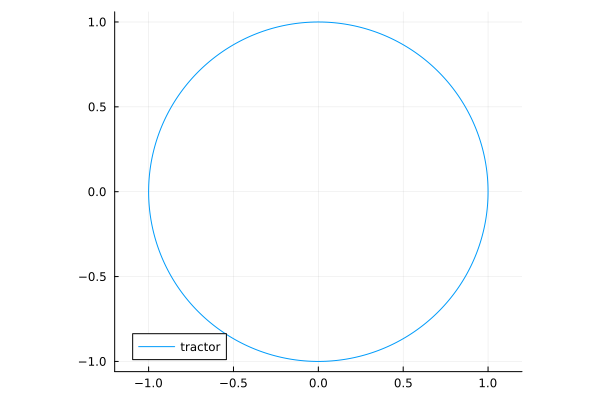

In [6]:
plot(tractorpath, aspectratio=1, label="tractor", xlims=(-1.2, 1.2))

To define the function for the trailer, we follow the syntax as required by the definition of the right hand side of the system of differential equations, as required by ``DifferentialEquations.jl``.

In [7]:
"""
    function trailer!(du::Vector{Float64}, u::Vector{Float64}, p, t)

defines the right hand side of the system for the trailer.
"""
function trailer!(du, u, p, t)
    x1p, x2p, x1v, x2v = tractor(t)
    du[1] = x1p - u[1]
    du[2] = x2p - u[2]
    nrm = sqrt(du[1]*du[1] + du[2]*du[2])
    du[1] = du[1]/nrm
    du[2] = du[2]/nrm
    vtu = x1v*du[1] + x2v*du[2]
    du[1] = vtu*du[1]
    du[2] = vtu*du[2]
end

trailer!

In [8]:
timespan = (0, 20)

(0, 20)

In [9]:
initconds = [2.0, 0.0]

2-element Vector{Float64}:
 2.0
 0.0

In [10]:
odetractrix = ODEProblem(trailer!, initconds, timespan)

ODEProblem with uType Vector{Float64} and tType Int64. In-place: true
Non-trivial mass matrix: false
timespan: (0, 20)
u0: 2-element Vector{Float64}:
 2.0
 0.0

In [11]:
soltractrix = solve(odetractrix)

retcode: Success
Interpolation: 3rd order Hermite
t: 39-element Vector{Float64}:
  0.0
  9.999999999999999e-5
  0.0010999999999999998
  0.011099999999999997
  0.045999325716980274
  0.09728271564001773
  0.16079176633117237
  0.24759896594881792
  0.36262237559272426
  0.520077325322635
  0.7440094177211165
  1.132116239089042
  1.52548947655565
  ⋮
 11.751909384886341
 12.524522872882429
 13.25444899712299
 14.03023014535575
 14.766932298520205
 15.543381425388024
 16.285765116457874
 17.060633599822346
 17.807953541691056
 18.57901960964357
 19.33086913837886
 20.0
u: 39-element Vector{Vector{Float64}}:
 [2.0, 0.0]
 [1.99999999, 6.666666593333332e-13]
 [1.999998790001098, 8.873321522941029e-10]
 [1.999876801384152, 9.116304443552371e-7]
 [1.9978874129707327, 6.473710469507343e-5]
 [1.9906026295655874, 0.0006074547393589874]
 [1.9746349289098342, 0.002694581765924437]
 [1.941353690674249, 0.00947654696819698]
 [1.8799939503400702, 0.027726712431016744]
 [1.772922636870178, 0.071837624

To plot the path of the trailer, we have to extract the coordinates, returned in the matrix sol.u, and store the coordinates as tuples.

In [12]:
trailerpath = [(x,y) for (x,y) in soltractrix.u]

39-element Vector{Tuple{Float64, Float64}}:
 (2.0, 0.0)
 (1.99999999, 6.666666593333332e-13)
 (1.999998790001098, 8.873321522941029e-10)
 (1.999876801384152, 9.116304443552371e-7)
 (1.9978874129707327, 6.473710469507343e-5)
 (1.9906026295655874, 0.0006074547393589874)
 (1.9746349289098342, 0.002694581765924437)
 (1.941353690674249, 0.00947654696819698)
 (1.8799939503400702, 0.027726712431016744)
 (1.772922636870178, 0.07183762411053551)
 (1.5958733923546977, 0.16714187224080201)
 (1.2706956967566, 0.372053179092874)
 (0.9432881690569128, 0.5589732146388726)
 ⋮
 (-0.11309919592609344, -0.12659921860323378)
 (0.006101419518942353, -0.15926681740250828)
 (0.10423174382238796, -0.10881765475369054)
 (0.1423332307353409, -0.0050205895034112396)
 (0.10372131976870878, 0.08699791948200472)
 (0.012813258306779476, 0.12802998087371253)
 (-0.07334287592643288, 0.09855910989154908)
 (-0.11584295476758899, 0.018566995179821723)
 (-0.09368332141138362, -0.06218184124152021)
 (-0.023112208632112212,

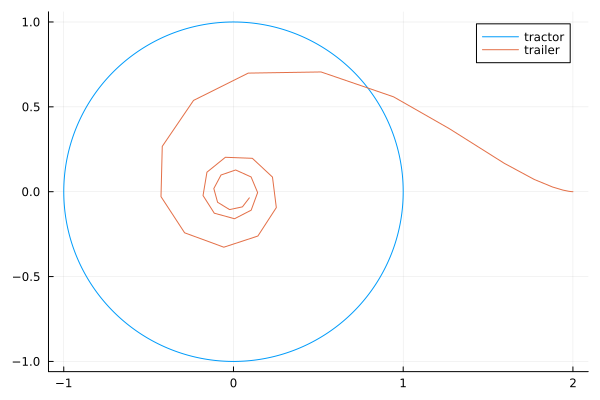

In [13]:
plot(tractorpath, label="tractor")
plot!(trailerpath, label="trailer")

In [14]:
# savefig("figtractortrailer.png")

To obtain a smoother path in the drawing, use the ``saveat`` option in the ``solve`` and ask to save at ``0.05``.

In [15]:
soltractrix2 = solve(odetractrix, saveat=0.05)

retcode: Success
Interpolation: 1st order linear
t: 401-element Vector{Float64}:
  0.0
  0.05
  0.1
  0.15
  0.2
  0.25
  0.3
  0.35
  0.4
  0.45
  0.5
  0.55
  0.6
  ⋮
 19.45
 19.5
 19.55
 19.6
 19.65
 19.7
 19.75
 19.8
 19.85
 19.9
 19.95
 20.0
u: 401-element Vector{Vector{Float64}}:
 [2.0, 0.0]
 [1.9975046758088275, 8.310418769264526e-5]
 [1.990074270806266, 0.0006594057371508452]
 [1.977871490528051, 0.002195544810899723]
 [1.9611546904934942, 0.005107714337163952]
 [1.9402605372999855, 0.009742783978296332]
 [1.9155826304019614, 0.016365614873067768]
 [1.8875491644398477, 0.025153410667667634]
 [1.8566003462497744, 0.03619674515220509]
 [1.8231711460194904, 0.04950400046495639]
 [1.7876726457001524, 0.06501466249701036]
 [1.750483849963239, 0.08260922112764692]
 [1.7119431842055919, 0.10212051915755188]
 ⋮
 [0.06256329887527222, -0.08186354021637646]
 [0.06639470166326628, -0.07844288588335285]
 [0.07004222706620733, -0.074845171368832]
 [0.07349823878925835, -0.0710801789259436]


In [16]:
trailerpath2 = [(x,y) for (x,y) in soltractrix2.u];

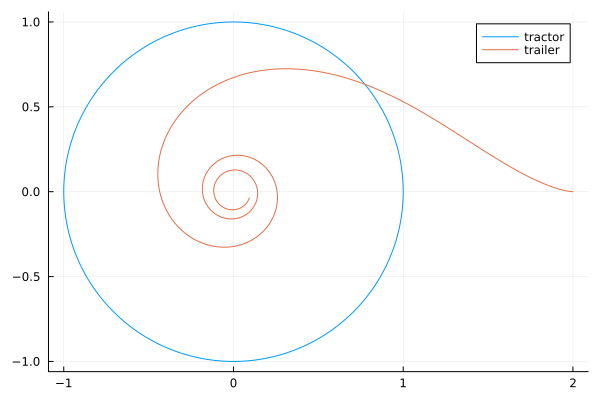

In [17]:
plot(tractorpath, label="tractor")
plot!(trailerpath2, label="trailer")

In [18]:
# savefig("figtractortrailer2.png")

### 1.2 an animation

The animation is defined by taking longer and longer slices of the paths for the tractor and the trailor.

We have to calculate the path of the tractor for the *same* time span as for the trailer.

In [19]:
runcircle2 = [tractor(t) for t in soltractrix2.t];
tractorpath2 = [(tpl[1],tpl[2]) for tpl in runcircle2];

To tests, let us plot the first half of the paths, for both the tractor and the trailer.

In [20]:
length(tractorpath2)

401

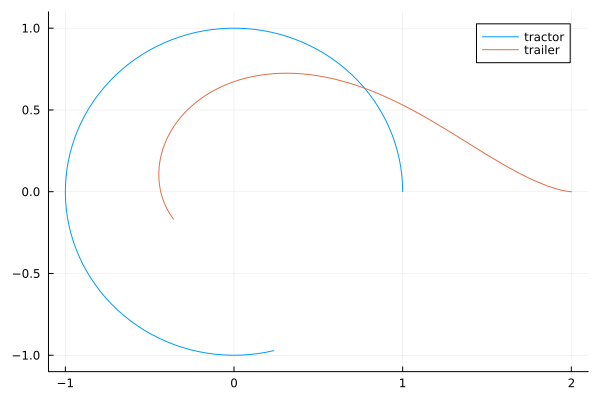

In [21]:
plot(tractorpath2[1:100], label="tractor", xlims=(-1.1,2.1), ylims = (-1.1, 1.1))
plot!(trailerpath2[1:100], label="trailer")

In [22]:
animTractorTrailer = Plots.Animation()
for i = 10:10:length(tractorpath2)
    plot(tractorpath2[1:i], label="tractor", 
         xlims=(-1.1,2.1), ylims = (-1.1, 1.1))
    (xtp1, xtp2) = tractorpath2[i]
    scatter!([xtp1], [xtp2], legend=false)
    plot!(trailerpath2[1:i], label="trailer")
    Plots.frame(animTractorTrailer)
end

To display the animation, create a gif and set the number of frames per second, defined by the ``fps`` keyword.

[ Info: Saved animation to C:\Users\jan\Courses\MCS472\Spring26\Lec31\tractortrailer2.gif


Plots.AnimatedGif("C:\\Users\\jan\\Courses\\MCS472\\Spring26\\Lec31\\tractortrailer2.gif")
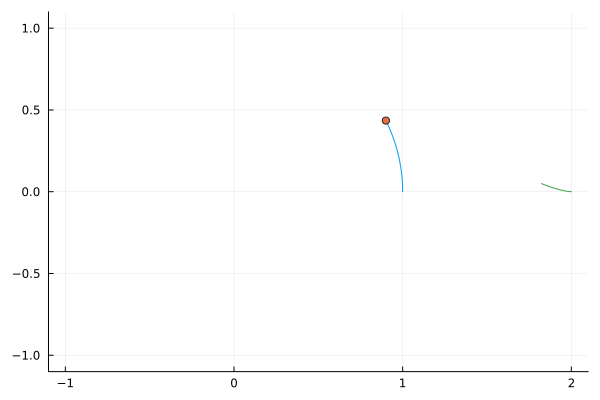

In [23]:
gif(animTractorTrailer, "tractortrailer2.gif", fps = 2)

### 2. A predator chasing a prey

To model the pursuit of a predator chasing a prey, we can use as the right hand side

$$
   y' = s(t) w,
$$

where

* $s(t)$ is the speed of the predator, and

* $w$ is the direction of the predator.

This direction is computed as before, as in the fuction ``trailer!``.

In [24]:
"""
    function predator!(du::Vector{Float64}, u::Vector{Float64}, p, t)

defines the right hand side of the system for the predator,
chasing a prey with accelerating speed.
"""
function predator!(du, u, p, t)
    x1p, x2p, x1v, x2v = tractor(t)
    acceleration = p
    speed = acceleration*t
    du[1] = x1p - u[1]
    du[2] = x2p - u[2]
    nrm = sqrt(du[1]*du[1] + du[2]*du[2])
    du[1] = speed*du[1]/nrm
    du[2] = speed*du[2]/nrm
end

predator!

We use the same initial conditions as before, but a shorter time span.
So we have to recompute the path for the prey.

In [25]:
timespan = (0, 13)
initconds = [2.0, 0.0]

2-element Vector{Float64}:
 2.0
 0.0

In [26]:
odepursuit = ODEProblem(predator!, initconds, timespan, 0.1)

ODEProblem with uType Vector{Float64} and tType Int64. In-place: true
Non-trivial mass matrix: false
timespan: (0, 13)
u0: 2-element Vector{Float64}:
 2.0
 0.0

In [27]:
solpursuit = solve(odepursuit, saveat=0.05)

retcode: Success
Interpolation: 1st order linear
t: 261-element Vector{Float64}:
  0.0
  0.05
  0.1
  0.15
  0.2
  0.25
  0.3
  0.35
  0.4
  0.45
  0.5
  0.55
  0.6
  ⋮
 12.45
 12.5
 12.55
 12.6
 12.65
 12.7
 12.75
 12.8
 12.85
 12.9
 12.95
 13.0
u: 261-element Vector{Vector{Float64}}:
 [2.0, 0.0]
 [1.9998750778887264, 4.159597965517512e-6]
 [1.9995012316255802, 3.310313742474092e-5]
 [1.9988811406436149, 0.00011079533730710966]
 [1.9980189596856712, 0.00025960153658833435]
 [1.996919978612553, 0.0004997436733466243]
 [1.9955901427906861, 0.0008488732040038899]
 [1.9940355856955507, 0.0013218976487160028]
 [1.9922623051970356, 0.0019309107814266078]
 [1.9902758266310197, 0.00268523174582479]
 [1.9880808246528034, 0.0035918992425774325]
 [1.9856810920602979, 0.004655710285866903]
 [1.9830795300528845, 0.005879332177740532]
 ⋮
 [0.9892277595876519, -0.11869327472412329]
 [0.9979261097777211, -0.06847826391966577]
 [0.9982699776819656, -0.017658997235478292]
 [0.998990272294804, 0.0332484

In [28]:
runcircle3 = [tractor(t) for t in solpursuit.t];
tractorpath3 = [(tpl[1],tpl[2]) for tpl in runcircle3];

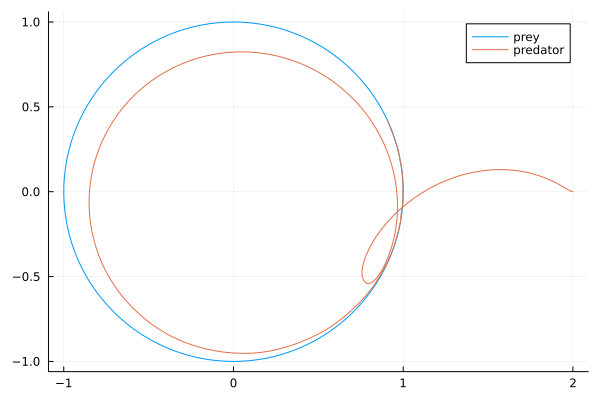

In [29]:
predatorpath = [(x,y) for (x,y) in solpursuit.u];
plot(tractorpath3, label="prey")
plot!(predatorpath, label="predator")

In [30]:
# savefig("figpredatorprey1.png")

In [31]:
animChasingPredator = Plots.Animation()
for i = 10:10:length(tractorpath3)
    plot(tractorpath3[1:i], label="tractor", 
         xlims=(-1.1,2.1), ylims = (-1.1, 1.1))
    (xtp1, xtp2) = tractorpath3[i]
    scatter!([xtp1], [xtp2], legend=false)
    plot!(predatorpath[1:i], label="predator")
    Plots.frame(animChasingPredator)
end

[ Info: Saved animation to C:\Users\jan\Courses\MCS472\Spring26\Lec31\chasingpredator2.gif


Plots.AnimatedGif("C:\\Users\\jan\\Courses\\MCS472\\Spring26\\Lec31\\chasingpredator2.gif")
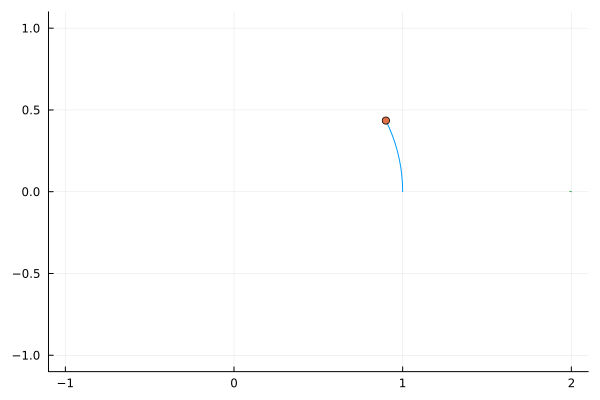

In [32]:
gif(animChasingPredator, "chasingpredator2.gif", fps = 2)